# PowerPredict - interaktivni pregled projekta

Ovaj notebook je kratak vodič kroz najbitnije ideje, odluke i rezultate projekta. Cilj nije da zameni kompletnu dokumentaciju, nego brz pregled problema, pripremljenih podataka, rada baseline modela, rada GRU modela, treniranja modela i rezultata.

Notebook očekuje da se pokreće iz root foldera projekta, tj. iz foldera `PowerPredict`.

In [9]:
from pathlib import Path
import inspect
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
LOGS_DIR = PROJECT_ROOT / "data" / "logs"
GRU_LOGS_DIR = LOGS_DIR / "gru_logs"
COMPARE_LOGS_DIR = LOGS_DIR / "compare_logs"
BASELINE_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "baseline_graphs"
GRU_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "gru_graphs"
COMPARE_GRAPHS_DIR = PROJECT_ROOT / "data" / "graphs" / "baseline_gru_compare_graphs"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

## 1. Problem i podaci

Projekat predviđa satnu potrošnju električne energije domaćinstva. Originalni podaci su vremenska serija, pa je bitno da se podela na train, validation i test radi po vremenskoj osi, a ne nasumično. Time se simulira realniji scenario: model uči iz prošlosti i proverava se na kasnijim periodima.

In [2]:
dataset_report_path = LOGS_DIR / "dataset_report.csv"
split_report_path = LOGS_DIR / "split_report.csv"

if dataset_report_path.exists():
    display(Markdown("### Dataset report"))
    display(pd.read_csv(dataset_report_path))

if split_report_path.exists():
    display(Markdown("### Train / validation / test split"))
    display(pd.read_csv(split_report_path))

### Dataset report

,Opis,Vrednost
0,Minimalna satna potrosnja Global_active_power,0.124
1,Maksimalna satna potrosnja Global_active_power,6.5605
2,Prosecna satna potrosnja Global_active_power,1.0913
3,Medijana satne potrosnje Global_active_power,0.8023
4,Procenat sati sa potrosnjom ispod ili jednako ...,39.33
5,Procenat sati sa potrosnjom ispod ili jednako ...,55.85
6,Zakljucak,"Veliki deo sati ima nisku potrosnju, pa procen..."


### Train / validation / test split

,Opis,Vrednost
0,Broj redova u train skupu,23671
1,Broj redova u validation skupu,5072
2,Broj redova u test skupu,5073
3,Train period,2006-12-24 00:00:00 - 2009-09-14 06:00:00
4,Validation period,2009-09-14 07:00:00 - 2010-04-18 14:00:00
5,Test period,2010-04-18 15:00:00 - 2010-11-25 23:00:00


## 2. Feature engineering

Model ne dobija samo sirovu potrošnju. Dodaju se vremenski atributi, lag vrednosti i rolling statistike. To pomaže modelu da uhvati dnevne, nedeljne i sezonske obrasce.

Posebno su bitni lag feature-i: `lag_1h`, `lag_24h`, `lag_168h`, jer daju direktnu istoriju potrošnje iz prethodnog sata, prethodnog dana i prethodne nedelje.

In [3]:
train_path = PROJECT_ROOT / "data" / "processed" / "split" / "train.csv"

if train_path.exists():
    train_sample = pd.read_csv(train_path, parse_dates=["datetime"]).head(10)
    display(train_sample)
    display(Markdown(f"Broj kolona u train skupu: **{len(train_sample.columns)}**"))

,datetime,Global_active_power,Global_reactive_power,Global_intensity,Energy_kWh,hour,day_of_week,month,is_weekend,is_night,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_std_7d,is_holiday
0,2006-12-24 00:00:00,4.0280,0.0907,17.0800,4.0280,0,6,12,1,1,5.5625,1.6982,1.8825,3.4119,1.2479,0
1,2006-12-24 01:00:00,3.2757,0.0518,14.0167,3.2757,1,6,12,1,1,4.0280,1.7228,3.3494,3.4766,1.2473,0
2,2006-12-24 02:00:00,2.3030,0.1037,10.0667,2.3030,2,6,12,1,1,3.2757,1.7008,1.5873,3.5017,1.2477,0
3,2006-12-24 03:00:00,1.6068,0.0719,7.3467,1.6068,3,6,12,1,1,2.3030,1.7715,1.6622,3.4949,1.2478,0
4,2006-12-24 04:00:00,1.5761,0.0679,7.2667,1.5761,4,6,12,1,1,1.6068,1.8916,2.2158,3.4817,1.2476,0
5,2006-12-24 05:00:00,1.6319,0.1085,7.5333,1.6319,5,6,12,1,1,1.5761,2.2291,1.9967,3.4568,1.2476,0
6,2006-12-24 06:00:00,1.8952,0.0507,8.4467,1.8952,6,6,12,1,1,1.6319,1.6494,1.3033,3.4671,1.2469,0
7,2006-12-24 07:00:00,1.4764,0.0997,6.9700,1.4764,7,6,12,1,0,1.8952,4.0234,1.6200,3.3609,1.2471,0
8,2006-12-24 08:00:00,1.4278,0.0523,6.5967,1.4278,8,6,12,1,0,1.4764,4.1908,1.8906,3.2458,1.2475,0
9,2006-12-24 09:00:00,2.7257,0.0939,11.8100,2.7257,9,6,12,1,0,1.4278,3.2464,2.5491,3.2241,1.2482,0


Broj kolona u train skupu: **16**

## 3. Baseline model

Baseline koristi jednostavno pravilo: predikcija za dati sat je vrednost iz istog sata prethodnog dana, tj. `lag_24h`. Ovo je korisna referentna tačka: GRU ima smisla samo ako jasno poboljšava rezultat u odnosu na ovako jednostavan model.

In [4]:
baseline_report_path = LOGS_DIR / "baseline_report.csv"

if baseline_report_path.exists():
    baseline_report = pd.read_csv(baseline_report_path)
    display(baseline_report[baseline_report["Report_Type"] == "summary"])
else:
    display(Markdown("Baseline report nije pronađen. Pokrenuti `python main.py`."))

,Report_Type,Dataset,Baseline,Hour,MAE,RMSE,MAPE,sMAPE,WAPE,Broj_redova
0,summary,validation,lag_24h,NaN,0.6624,0.9550,74.7894,52.0735,53.0450,5072
1,summary,test,lag_24h,NaN,0.5123,0.7611,66.8003,49.2873,53.4677,5073


### baseline_test_hourly_mae.png

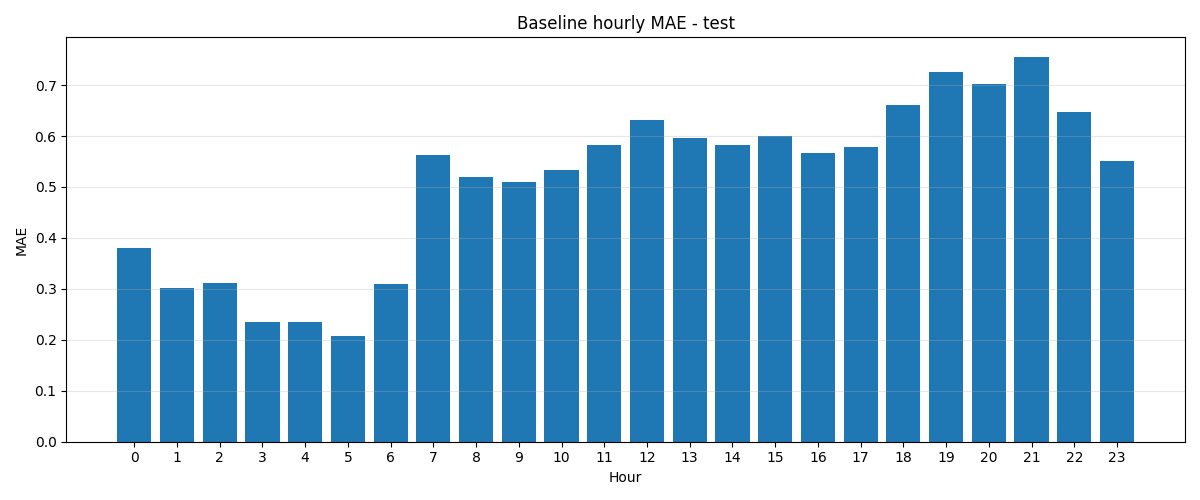

### baseline_test_hourly_wape.png

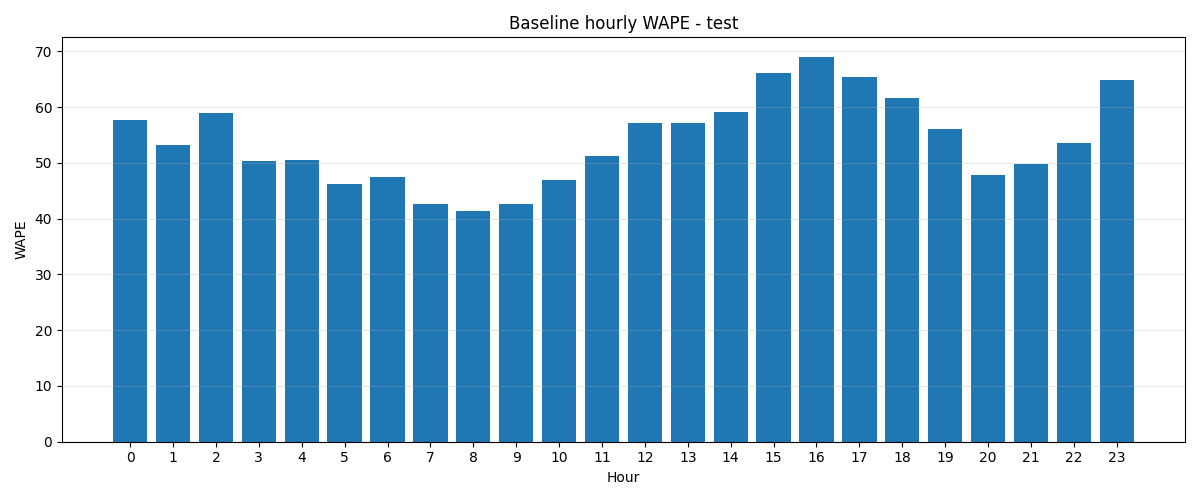

### baseline_test_actual_vs_predicted_scatter.png

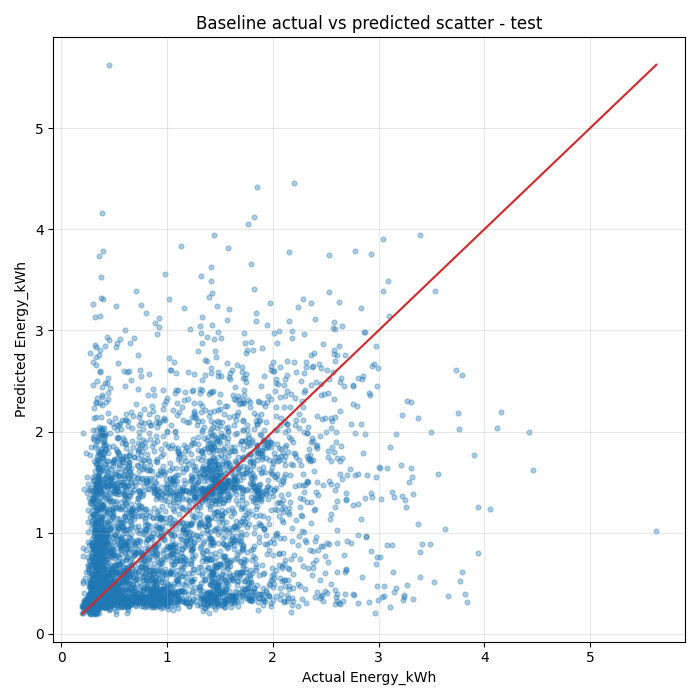

### baseline_test_error_distribution.png

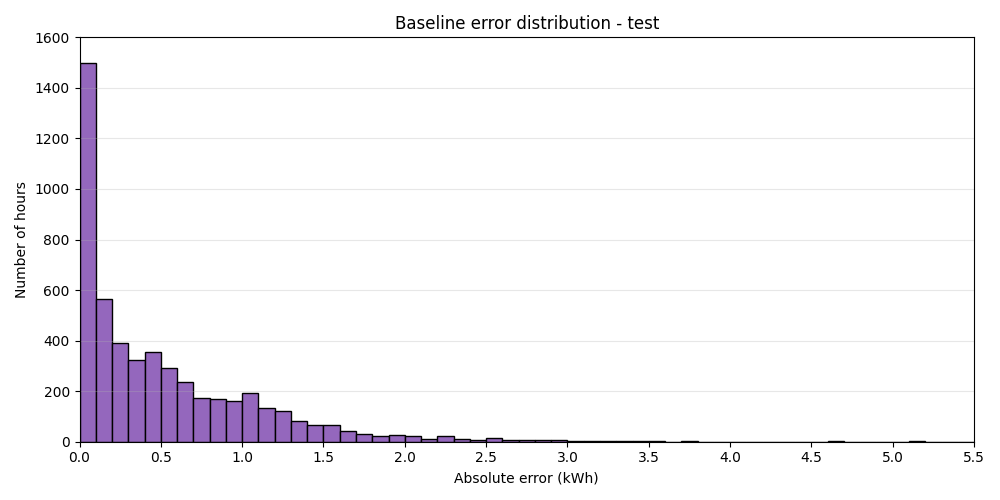

In [5]:
baseline_graphs = [
    "baseline_test_hourly_mae.png",
    "baseline_test_hourly_wape.png",
    "baseline_test_actual_vs_predicted_scatter.png",
    "baseline_test_error_distribution.png",
]

for graph_name in baseline_graphs:
    graph_path = BASELINE_GRAPHS_DIR / graph_name
    if graph_path.exists():
        display(Markdown(f"### {graph_name}"))
        display(Image(filename=str(graph_path)))

## 4. GRU ideja

GRU, Gated Recurrent Unit, je rekurentna neuronska mreža za sekvencijalne podatke. U ovom projektu jedna ulazna sekvenca predstavlja prethodna 24 sata. Za svaki sat u sekvenci model vidi sve ulazne feature-e, zatim GRU kroz svoje interno skriveno stanje pravi sažetak te istorije.

U kodu je finalna predikcija napravljena tako što se uzima izlaz poslednjeg vremenskog koraka GRU sloja i šalje u linearni sloj koji daje jednu vrednost: predikciju `Energy_kWh`.

In [10]:
from src import step06_gru_model as gru

display(Markdown("### Testirane GRU konfiguracije"))
display(pd.DataFrame(gru.HYPERPARAMETER_CONFIGS))

### Testirane GRU konfiguracije

,name,sequence_length,batch_size,hidden_size,num_layers,dropout,learning_rate,max_epochs,patience
0,gru_seq24_h32_l1_d0_lr0.001_bs64,24,64,32,1,0.0,0.0010,80,10
1,gru_seq24_h64_l2_d0.2_lr0.001_bs64,24,64,64,2,0.2,0.0010,80,10
2,gru_seq24_h128_l2_d0.3_lr0.0005_bs64,24,64,128,2,0.3,0.0005,80,10


In [ ]:
display(Markdown("### Ključni deo arhitekture iz `step06_gru_model.py`"))
print(inspect.getsource(gru.build_gru_model_class))

## 5. Kako se prave sekvence

Za svaki target sat pravi se prozor prethodnih `sequence_length` sati. Kod trenutnih konfiguracija `sequence_length = 24`, pa model za jednu predikciju gleda prethodna 24 sata.

Validation sekvence koriste kraj train skupa kao istorijski kontekst za prve validation sate. Test sekvence koriste kraj validation skupa kao istorijski kontekst za prve test sate. To ne znači da se model trenira na validation/test skupu; to samo obezbeđuje da prvi sati imaju prethodna 24 sata istorije.

In [11]:
display(Markdown("### Ključni deo pravljenja sekvenci"))
print(inspect.getsource(gru.create_sequences))

### Ključni deo pravljenja sekvenci

def create_sequences(
    context_df,
    eval_df,
    feature_columns,
    feature_scaler,
    target_scaler,
    sequence_length=DEFAULT_SEQUENCE_LENGTH,
):
    """
    Kreira GRU sekvence koristeci istoriju iz context_df i targete iz eval_df.
    """
    combined_df = pd.concat(
        [context_df.tail(sequence_length), eval_df],
        ignore_index=True,
    )

    features = feature_scaler.transform(
        combined_df[feature_columns].to_numpy(dtype=np.float32)
    )
    targets = target_scaler.transform(
        combined_df[[TARGET_COLUMN]].to_numpy(dtype=np.float32)
    ).reshape(-1)

    x_values = []
    y_values = []
    datetimes = []
    actual_values = []

    first_eval_index = len(context_df.tail(sequence_length))

    for target_index in range(first_eval_index, len(combined_df)):
        sequence_start = target_index - sequence_length

        if sequence_start < 0:
            continue

        time_window = combined_df.loc[sequence_start:target_index, "datetime"]


## 6. Trening, validation i early stopping

Model se trenira samo na train skupu. Validation skup se koristi za praćenje validation loss-a i early stopping. Ako se validation loss ne poboljša `patience` epoha zaredom, trening se prekida i vraća se najbolja sačuvana verzija modela.

In [12]:
display(Markdown("### Ključni deo trening petlje"))
print(inspect.getsource(gru.train_one_epoch))
print(inspect.getsource(gru.evaluate_loss))
print(inspect.getsource(gru.train_gru_model))

### Ključni deo trening petlje

def train_one_epoch(torch, model, data_loader, loss_fn, optimizer, device):
    """
    Trenira model tokom jedne epohe.
    """
    model.train()
    losses = []

    for x_batch, y_batch in data_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        prediction = model(x_batch)
        loss = loss_fn(prediction, y_batch)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))

def evaluate_loss(torch, model, data_loader, loss_fn, device):
    """
    Racuna loss bez treniranja.
    """
    model.eval()
    losses = []

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            prediction = model(x_batch)
            loss = loss_fn(prediction, y_batch)
            losses.append(loss.item())

    return float(np.mean(losses))

def train_gru_model(model, 

## 7. Training history grafovi

Ovi grafovi pokazuju kako se menjaju `train_loss` i `validation_loss` kroz epohe. Najkorisniji su za objašnjenje overfitting-a i early stopping-a: ako train loss nastavlja da opada, a validation loss prestane da se poboljšava, model počinje sve više da se prilagođava train skupu umesto da bolje generalizuje.

In [13]:
history_paths = sorted(GRU_LOGS_DIR.glob("*_training_history.csv"))

history_summary_rows = []
for path in history_paths:
    model_name = path.stem.removesuffix("_training_history")
    history_df = pd.read_csv(path)
    best_idx = history_df["validation_loss"].idxmin()
    best_row = history_df.loc[best_idx]
    history_summary_rows.append({
        "Model": model_name,
        "stopped_epoch": int(history_df["epoch"].iloc[-1]),
        "best_validation_epoch": int(best_row["epoch"]),
        "best_validation_loss": best_row["validation_loss"],
        "train_loss_at_best_validation": best_row["train_loss"],
        "final_train_loss": history_df["train_loss"].iloc[-1],
        "final_validation_loss": history_df["validation_loss"].iloc[-1],
    })

history_summary = pd.DataFrame(history_summary_rows)
display(history_summary)

,Model,stopped_epoch,best_validation_epoch,best_validation_loss,train_loss_at_best_validation,final_train_loss,final_validation_loss
0,gru_seq24_h128_l2_d0.3_lr0.0005_bs64,14,4,0.344135,0.376920,0.339981,0.348394
1,gru_seq24_h32_l1_d0_lr0.001_bs64,22,12,0.342625,0.344996,0.326292,0.352151
2,gru_seq24_h64_l2_d0.2_lr0.001_bs64,14,4,0.341442,0.374112,0.334450,0.358748


### gru_seq24_h128_l2_d0.3_lr0.0005_bs64

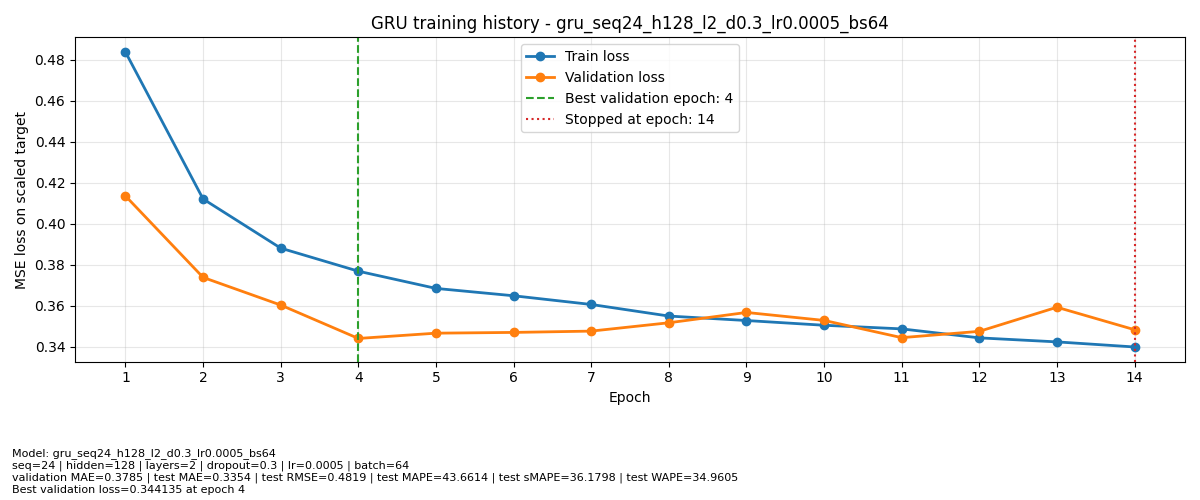

### gru_seq24_h32_l1_d0_lr0.001_bs64

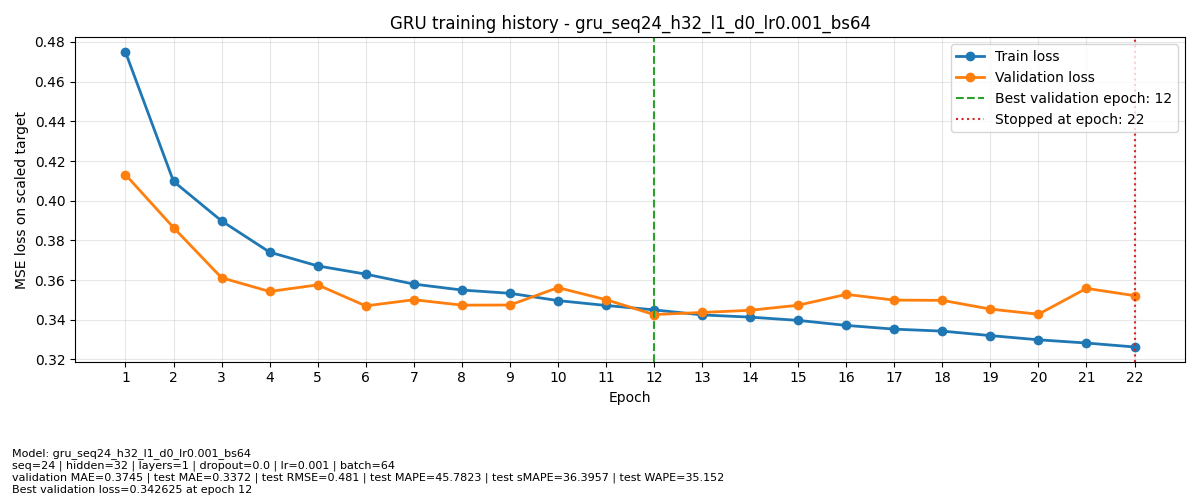

### gru_seq24_h64_l2_d0.2_lr0.001_bs64

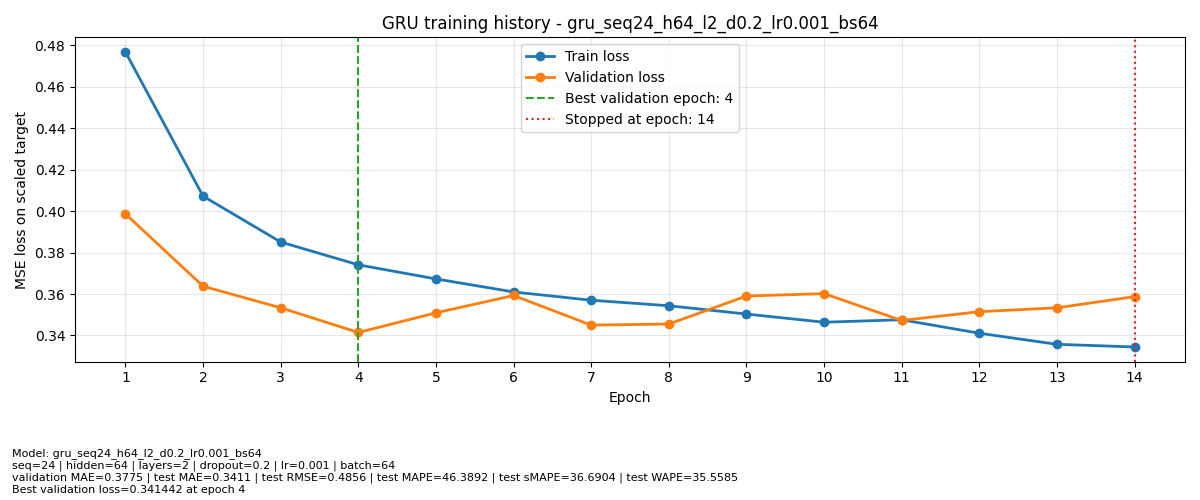

In [14]:
for row in history_summary.itertuples(index=False):
    graph_path = GRU_GRAPHS_DIR / f"{row.Model}_training_history.png"
    if graph_path.exists():
        display(Markdown(f"### {row.Model}"))
        display(Image(filename=str(graph_path)))

## 8. Rezultati GRU konfiguracija

Najbolja konfiguracija bira se po validation MAE, a test metrike se koriste za finalno izveštavanje.

In [15]:
summaries_path = GRU_LOGS_DIR / "gru_model_summaries.csv"
best_summary_path = GRU_LOGS_DIR / "best_gru_model_summary.csv"

if summaries_path.exists():
    gru_summaries = pd.read_csv(summaries_path)
    display(gru_summaries.sort_values("validation_MAE"))

if best_summary_path.exists():
    display(Markdown("### Najbolji GRU po validation MAE"))
    display(pd.read_csv(best_summary_path))

,Model,sequence_length,batch_size,hidden_size,num_layers,dropout,learning_rate,max_epochs,patience,validation_MAE,validation_RMSE,validation_MAPE,validation_sMAPE,validation_WAPE,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_WAPE
1,gru_seq24_h32_l1_d0_lr0.001_bs64,24,64,32,1,0.0,0.0010,80,10,0.3745,0.5403,39.1649,31.8706,30.0027,0.3372,0.4810,45.7823,36.3957,35.1520
2,gru_seq24_h64_l2_d0.2_lr0.001_bs64,24,64,64,2,0.2,0.0010,80,10,0.3775,0.5395,39.9694,32.3700,30.2421,0.3411,0.4856,46.3892,36.6904,35.5585
0,gru_seq24_h128_l2_d0.3_lr0.0005_bs64,24,64,128,2,0.3,0.0005,80,10,0.3785,0.5417,40.4736,32.7553,30.3268,0.3354,0.4819,43.6614,36.1798,34.9605


### Najbolji GRU po validation MAE

,Model,selection_metric,sequence_length,batch_size,hidden_size,num_layers,dropout,learning_rate,max_epochs,patience,validation_MAE,validation_RMSE,validation_MAPE,validation_sMAPE,validation_WAPE,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_WAPE
0,gru_seq24_h32_l1_d0_lr0.001_bs64,validation_MAE,24,64,32,1,0.0,0.001,80,10,0.3745,0.5403,39.1649,31.8706,30.0027,0.3372,0.481,45.7823,36.3957,35.152


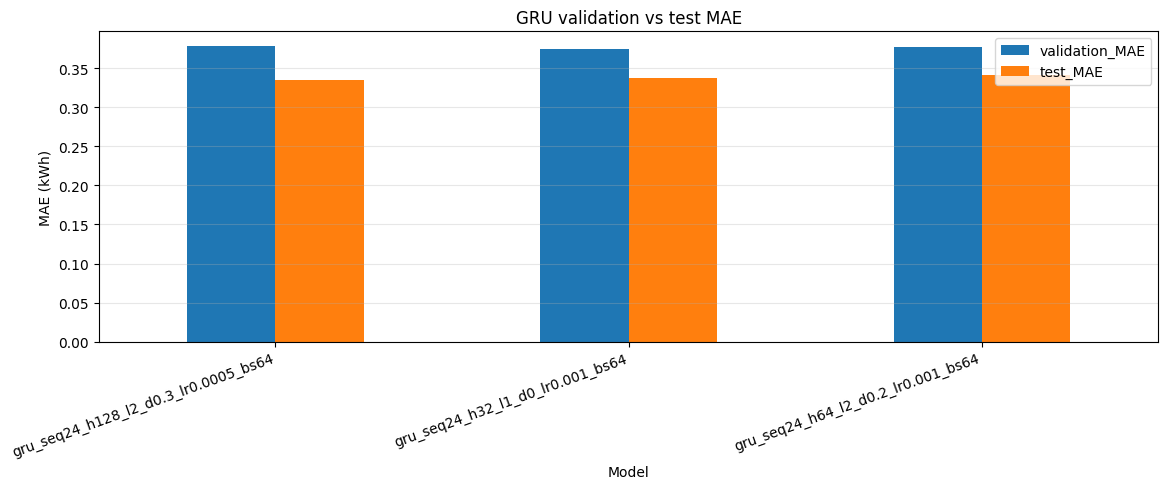

In [16]:
if summaries_path.exists():
    plot_df = pd.read_csv(summaries_path).set_index("Model")
    ax = plot_df[["validation_MAE", "test_MAE"]].plot(kind="bar", figsize=(12, 5))
    ax.set_title("GRU validation vs test MAE")
    ax.set_ylabel("MAE (kWh)")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

## 9. GRU grafovi na test skupu

Za svaku konfiguraciju postoje grafovi greške po satu, scatter odnos stvarnih i predviđenih vrednosti i distribucija apsolutne greške. Ovi grafovi pokazuju ne samo koliko model greši u proseku, nego i kada i kako greši.

## gru_seq24_h128_l2_d0.3_lr0.0005_bs64

### test_hourly_mae.png

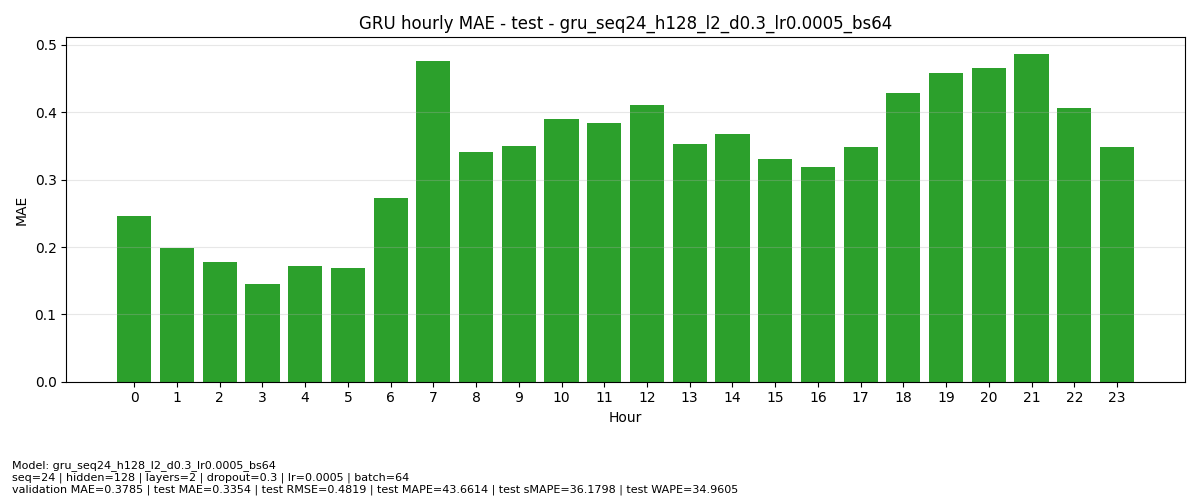

### test_hourly_wape.png

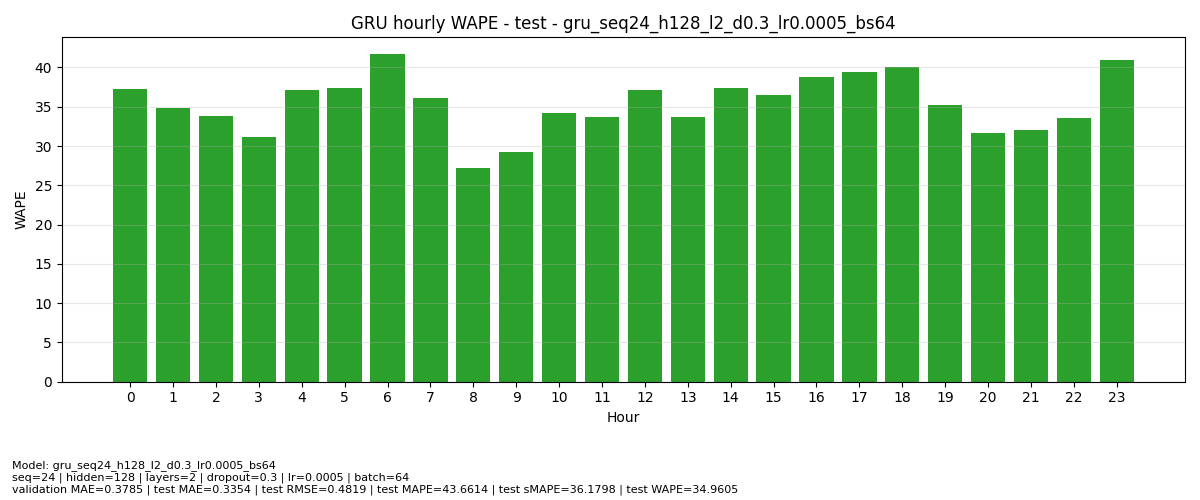

### test_actual_vs_predicted_scatter.png

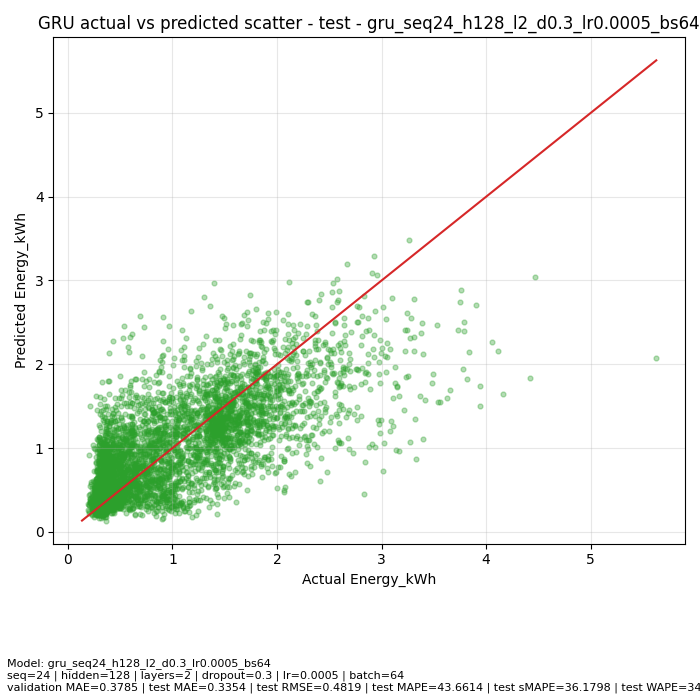

### test_error_distribution.png

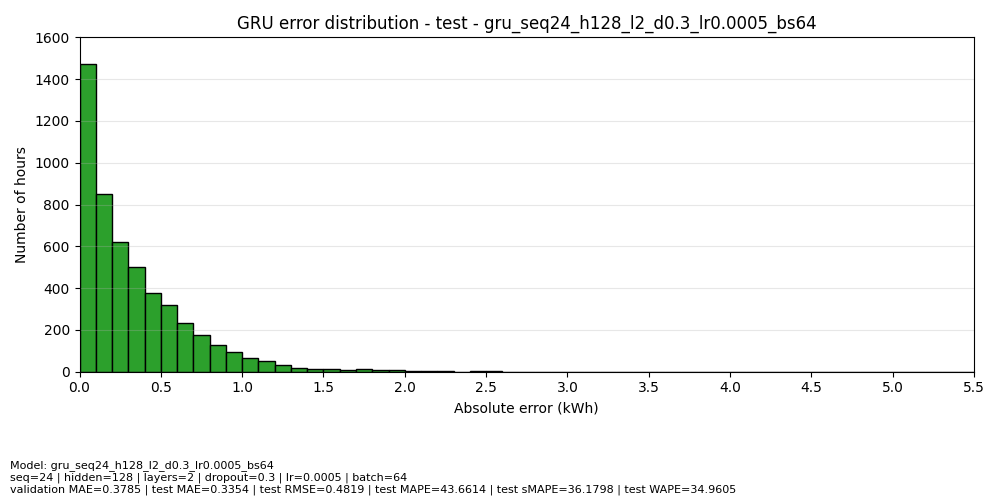

## gru_seq24_h32_l1_d0_lr0.001_bs64

### test_hourly_mae.png

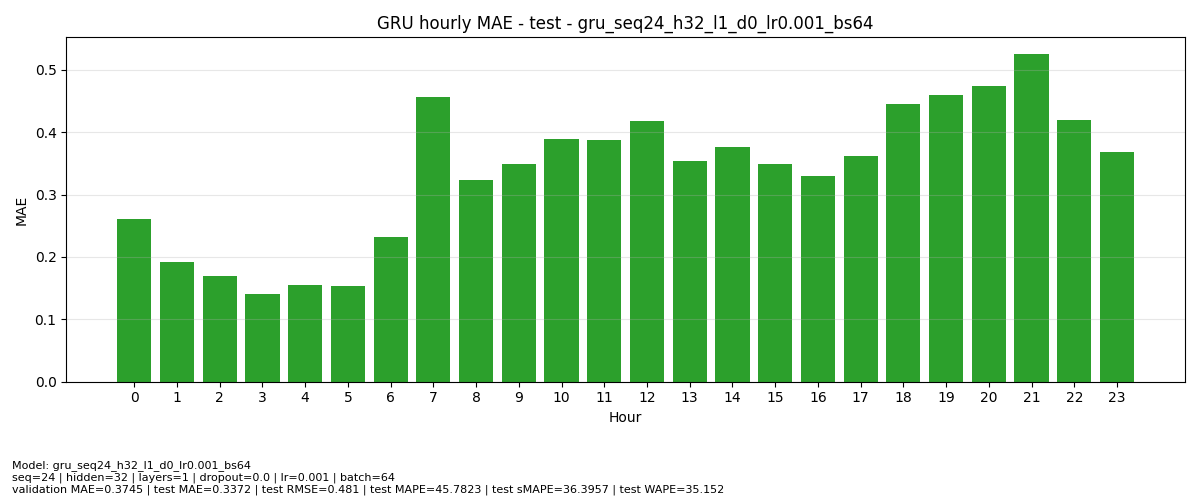

### test_hourly_wape.png

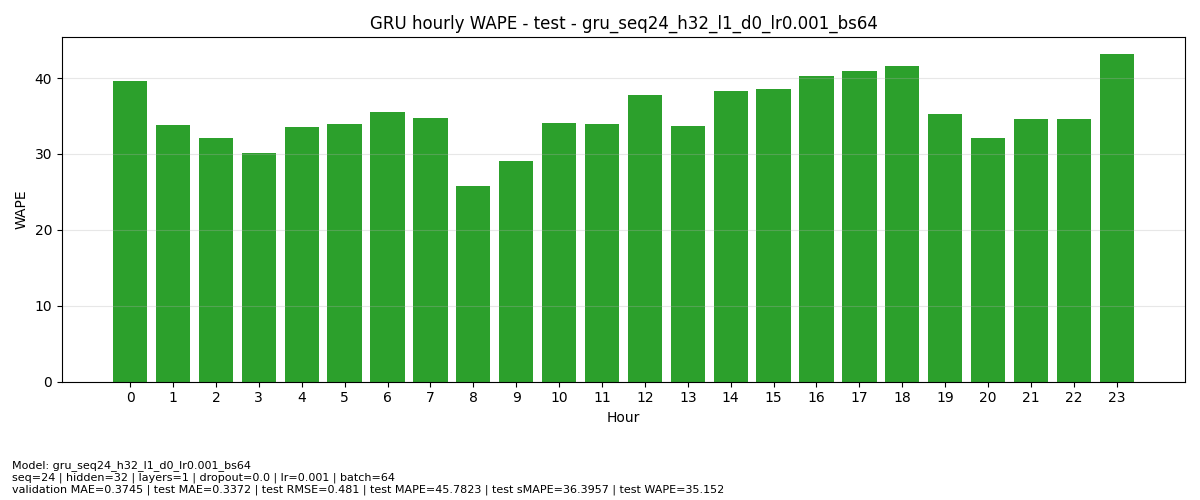

### test_actual_vs_predicted_scatter.png

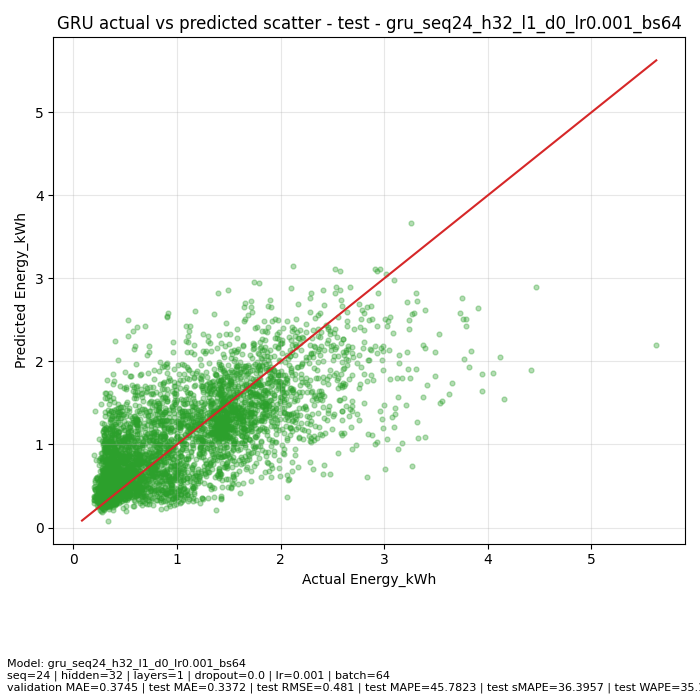

### test_error_distribution.png

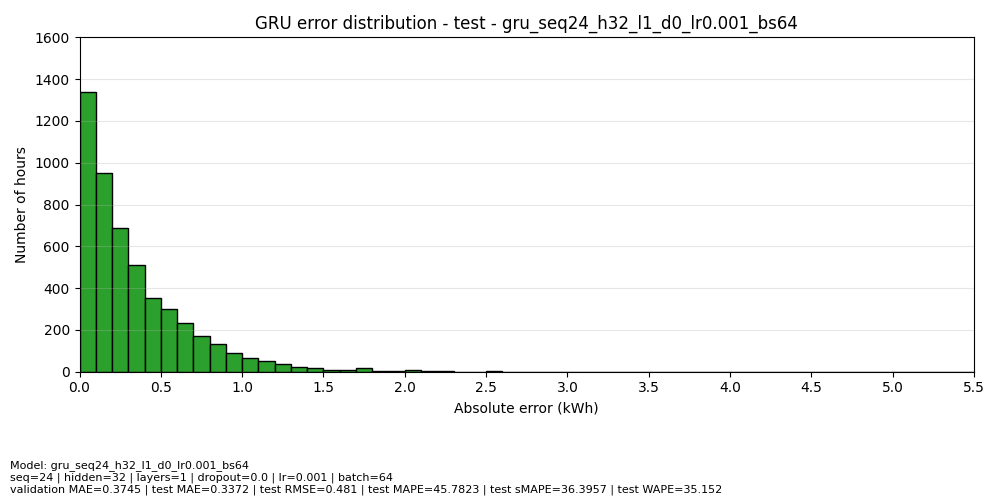

## gru_seq24_h64_l2_d0.2_lr0.001_bs64

### test_hourly_mae.png

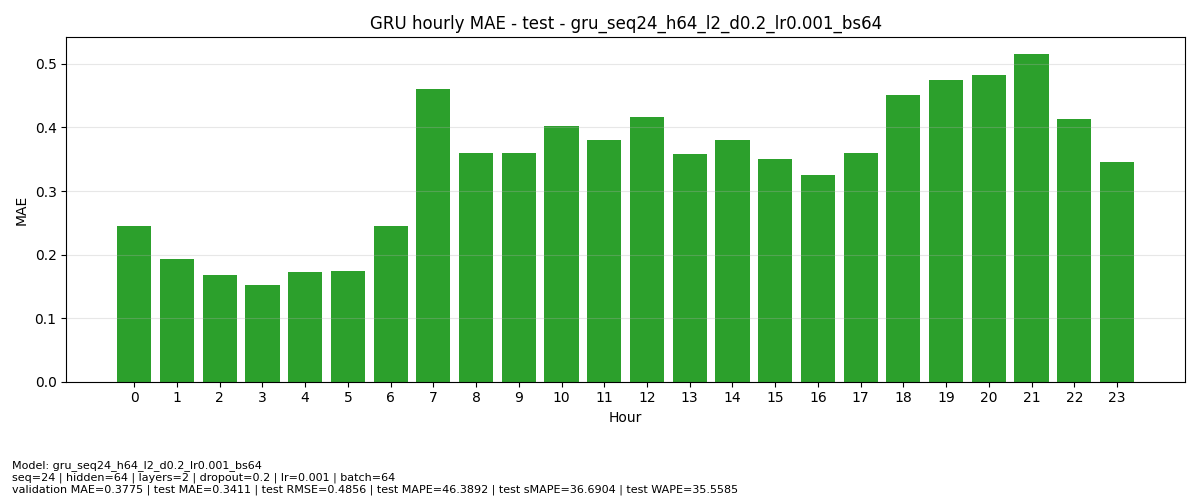

### test_hourly_wape.png

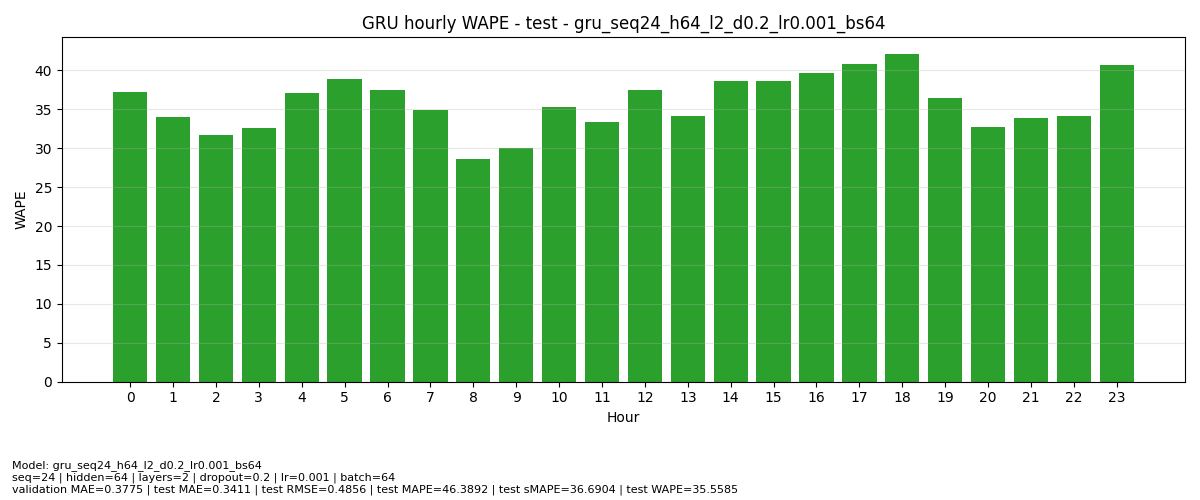

### test_actual_vs_predicted_scatter.png

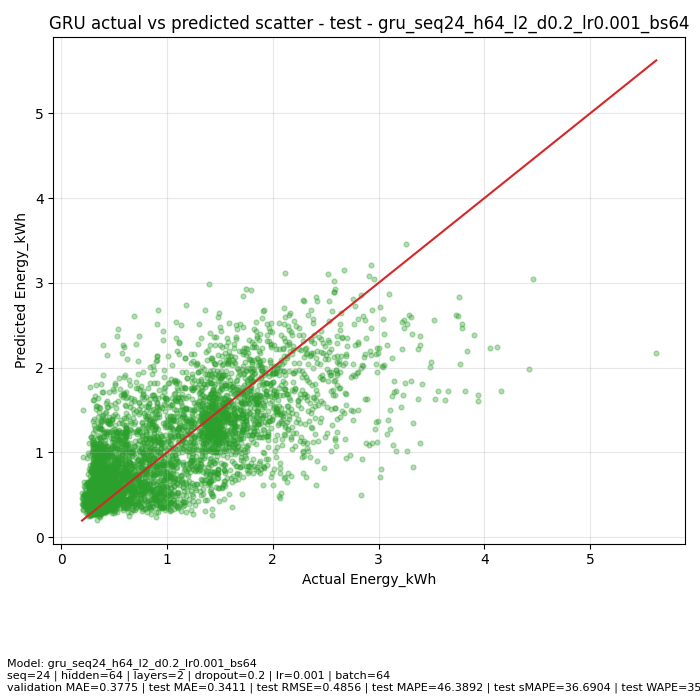

### test_error_distribution.png

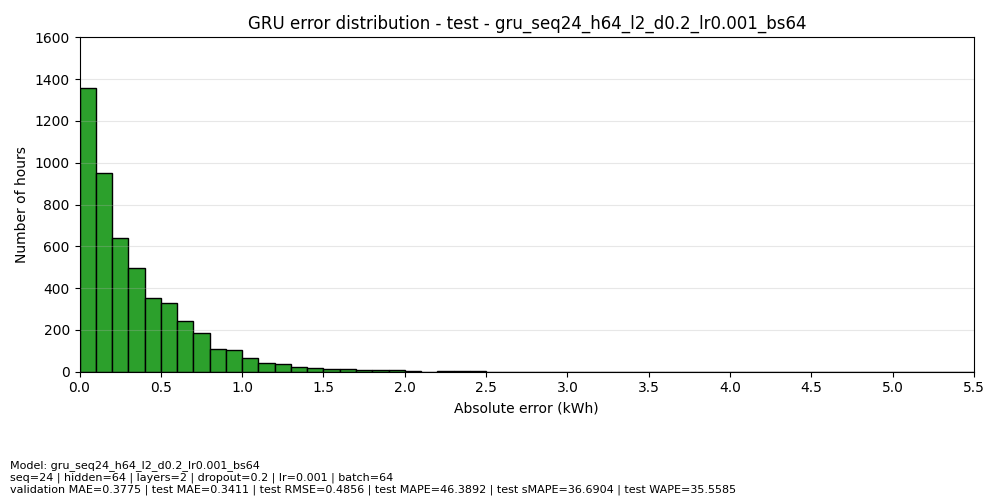

In [17]:
if summaries_path.exists():
    model_names = pd.read_csv(summaries_path)["Model"].tolist()
else:
    model_names = sorted(path.name.split("_test_")[0] for path in GRU_GRAPHS_DIR.glob("*_test_hourly_mae.png"))

selected_graph_suffixes = [
    "test_hourly_mae.png",
    "test_hourly_wape.png",
    "test_actual_vs_predicted_scatter.png",
    "test_error_distribution.png",
]

for model_name in model_names:
    display(Markdown(f"## {model_name}"))
    for suffix in selected_graph_suffixes:
        graph_path = GRU_GRAPHS_DIR / f"{model_name}_{suffix}"
        if graph_path.exists():
            display(Markdown(f"### {suffix}"))
            display(Image(filename=str(graph_path)))

## 10. Baseline vs najbolji GRU

Ovaj deo direktno odgovara na glavno pitanje: da li GRU donosi poboljšanje u odnosu na `lag_24h` baseline.

,Report_Type,Dataset,Hour,Broj_redova,Better_Model_by_MAE,Baseline_MAE,GRU_MAE,MAE_Improvement_percent,Baseline_RMSE,GRU_RMSE,RMSE_Improvement_percent,Baseline_MAPE,GRU_MAPE,MAPE_Improvement_percent,Baseline_sMAPE,GRU_sMAPE,sMAPE_Improvement_percent,Baseline_WAPE,GRU_WAPE,WAPE_Improvement_percent
0,summary,test,NaN,5025,gru_seq24_h32_l1_d0_lr0.001_bs64,0.5123,0.3372,34.1792,0.7611,0.481,36.802,66.8003,45.7823,31.4639,49.2873,36.3957,26.156,53.4677,35.152,34.2556


### best_gru_seq24_h32_l1_d0_lr0.001_bs64_baseline_gru_compare_test_actual_vs_predicted_scatter.png

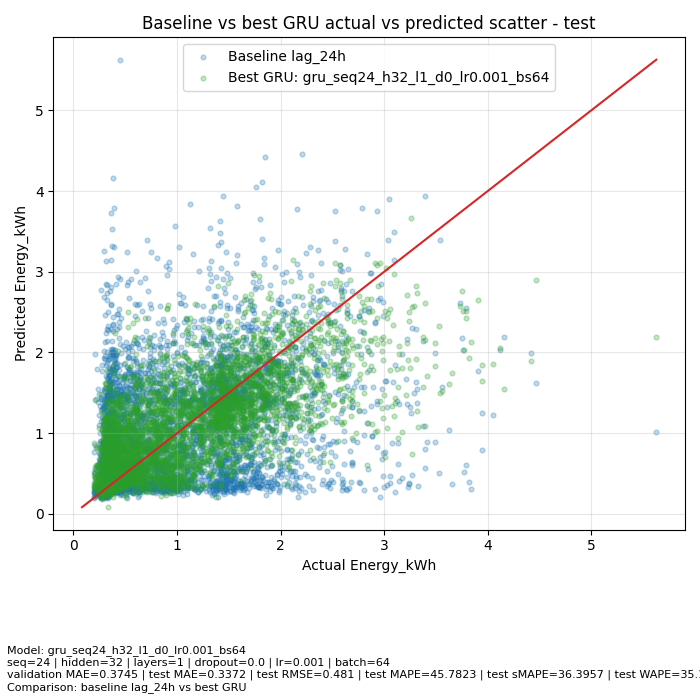

### best_gru_seq24_h32_l1_d0_lr0.001_bs64_baseline_gru_compare_test_error_distribution.png

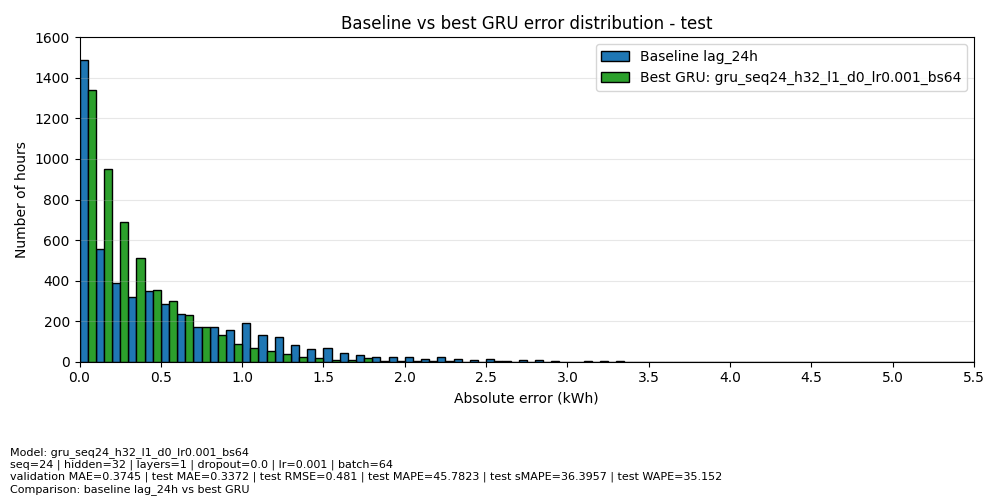

### best_gru_seq24_h32_l1_d0_lr0.001_bs64_baseline_gru_compare_test_hourly_mae.png

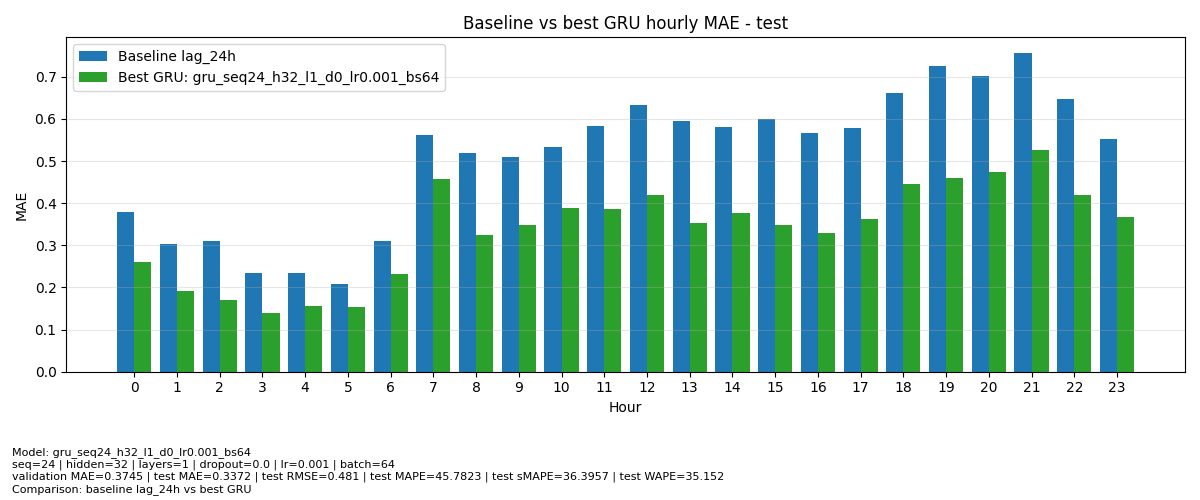

### best_gru_seq24_h32_l1_d0_lr0.001_bs64_baseline_gru_compare_test_hourly_wape.png

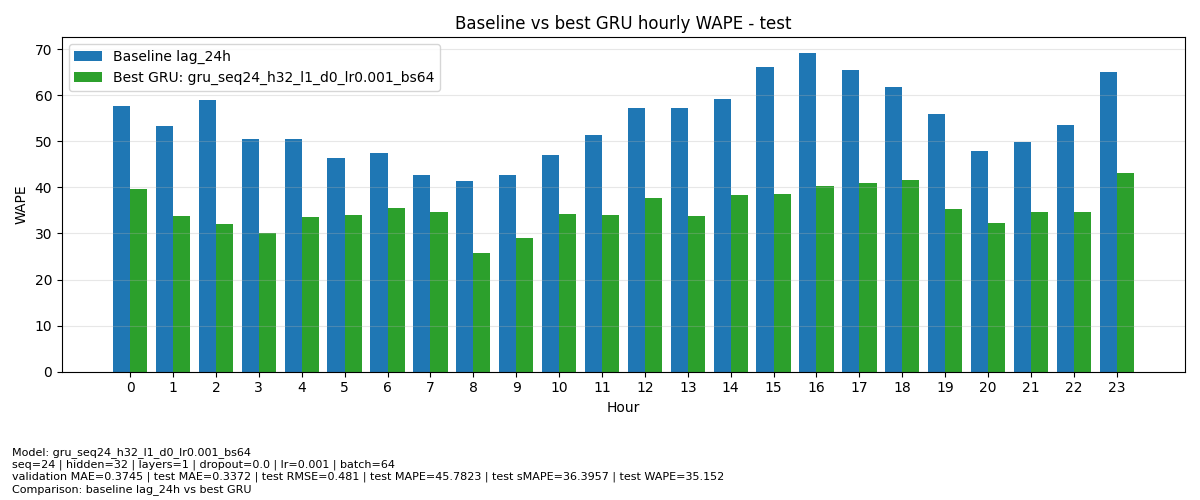

In [18]:
compare_report_path = COMPARE_LOGS_DIR / "baseline_gru_compare_report.csv"

if compare_report_path.exists():
    compare_report = pd.read_csv(compare_report_path)
    display(compare_report[compare_report["Report_Type"] == "summary"])

for graph_path in sorted(COMPARE_GRAPHS_DIR.glob("*.png")):
    display(Markdown(f"### {graph_path.name}"))
    display(Image(filename=str(graph_path)))

## 11. Zaključci iz rezultata

- Najbolja konfiguracija po glavnom kriterijumu izbora, `validation_MAE`, jeste `gru_seq24_h32_l1_d0_lr0.001_bs64`. Ona ima `validation_MAE = 0.3745`, što je najmanja validation greška među testirane tri GRU konfiguracije.
- Ovaj rezultat je zanimljiv zato što je najbolji model ujedno i najjednostavniji: `hidden_size = 32`, jedan GRU sloj i bez dropout-a. Veće konfiguracije (`h64/l2` i `h128/l2`) nisu donele bolju generalizaciju na validation skupu, iako imaju više parametara.
- Prva konfiguracija se trenirala najduže: stala je u 22. epohi, a najbolji validation loss ostvarila je u 12. epohi. Preostale dve konfiguracije stale su ranije, u 14. epohi, što ukazuje da je kod njih validation loss ranije prestao da se poboljšava.
- Na test skupu sve GRU konfiguracije su veoma blizu. Model izabran po validation MAE ima `test_MAE = 0.3372`, dok konfiguracija `h128/l2` ima nešto niži `test_MAE = 0.3354`. Ipak, po ispravnoj proceduri izbor se ne menja prema test rezultatu, jer test služi za završnu proveru, a ne za biranje hiperparametara.
- U odnosu na baseline `lag_24h`, izabrani GRU značajno smanjuje grešku: test MAE pada sa `0.5123` na `0.3372`, što je poboljšanje od oko `34.18%`. RMSE se smanjuje za oko `36.80%`, a WAPE sa `53.47%` na `35.15%`.
- Najveće apsolutne greške izabranog GRU modela na test skupu javljaju se u večernjim satima, posebno oko 18h-23h. Najveći hourly MAE je oko 21h (`0.5257 kWh`), zatim oko 20h (`0.4741 kWh`) i 19h (`0.4590 kWh`). To sugeriše da je večernja potrošnja promenljivija i teža za predikciju.
- Najbolji sati za predikciju su noćni i rani jutarnji periodi. Najniži hourly MAE je oko 3h (`0.1402 kWh`), 5h (`0.1527 kWh`), 4h (`0.1555 kWh`) i 2h (`0.1692 kWh`). To ima smisla jer je potrošnja tada stabilnija i manje zavisi od dnevnih aktivnosti ukućana.
- Training history grafovi pokazuju tipičan obrazac: train loss nastavlja da opada, dok validation loss posle određene epohe prestaje stabilno da se poboljšava. Zbog toga early stopping ima smisla, jer sprečava da se model dodatno prilagođava train skupu bez realnog poboljšanja na validation skupu.
- Glavni zaključak je da GRU uspešno koristi širi vremenski kontekst od 24 sata i dodatne feature-e, ali da za ovaj dataset složenija arhitektura nije automatski bolja. Jednostavniji GRU se pokazao kao stabilniji izbor za generalizaciju.